In [64]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('aps.mplstyle')
import set_size_helper as ssh
# importlib.reload(ssh)

from scipy.fftpack import fft
from matplotlib.lines import Line2D
from copy import copy

In [12]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)

idmrg_file = '../../data/iDMRG/scanChi800/corrs/results.h5'
df_i = read_corrs(idmrg_file)

df_fes = read_corrs('../../data/iDMRG/Vpm4.350cc/corrs/results.h5')
df_fes['chi'] = df_fes['src_file'].apply(lambda row : int(row.split('chi')[1].split('.')[0]))
df_fes = df_fes.sort_values('chi')

/tmp/ipykernel_292882/3217431333.py:18: RuntimeWarning: divide by zero encountered in power
  ax[0].plot(xarr, prefixes[j] * (xarr)**(-4/Ks), ls=':')
/tmp/ipykernel_292882/3217431333.py:76: RuntimeWarning: divide by zero encountered in power
  ax[1].plot(xarr, prefixes[j] * (xarr)**(powerlaw), ls=':')
/tmp/ipykernel_292882/3217431333.py:109: RuntimeWarning: divide by zero encountered in log
  axin1.plot(xvals, np.exp(m * np.log(xvals) + c), ls='--', c='k', alpha=1, label=rf'$\!\!\sim\!\!\exp\!|x|^{{{m:.3f}}}$')


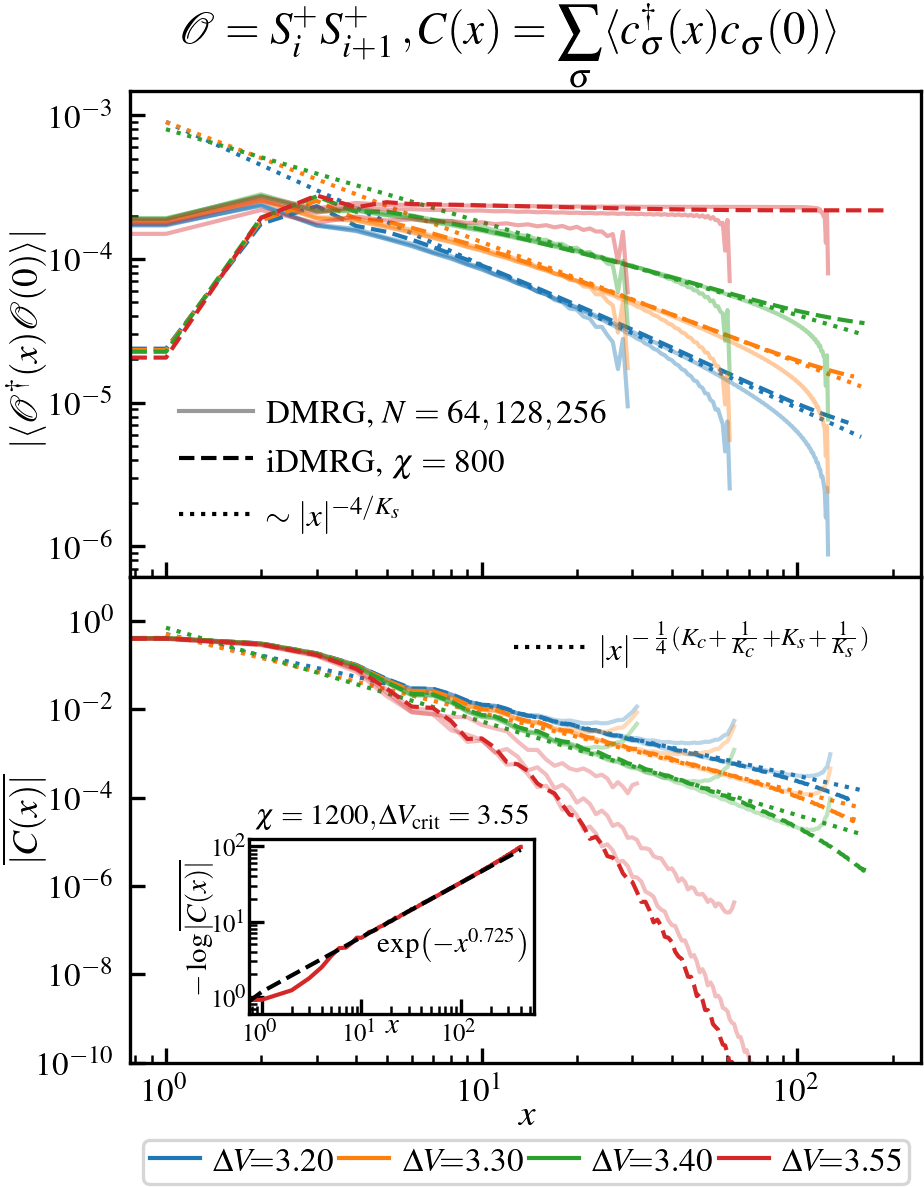

In [90]:
fig, ax = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0.00)
fig_width = ssh.set_size_ht(fraction=1.0, subplots=(2, 1))
fig.set_size_inches(fig_width)
dVvals = [3.2, 3.3, 3.4, 3.55, ]
prefixes = np.array([0.0009,0.0009, 0.0008, 1])
for j, dVval in enumerate(dVvals):
    col = f'C{j}'
    seldf_i = select_dV(df_i, dVval, atol=1e-7)
    ax[0].plot(np.abs(seldf_i["spin2_corr"].values[0]), c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
    for nval in (64, 128, 256,):
        label = r'$\Delta V\!\!\!\!= $' + f'{dVval:.2f}' if nval==256 else None
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        ax[0].plot(np.abs(seldf["spin2vec"].values[0]), c=col, alpha=0.4, label=label)
        if dVval < 3.55 and nval == 256: 
            xarr = np.arange(160)
            Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)
            ax[0].plot(xarr, prefixes[j] * (xarr)**(-4/Ks), ls=':')
        
ax[0].set_ylabel(r'$|\langle \mathcal{O}^\dagger(x)\mathcal{O}(0)\rangle|$',labelpad=1)
ax[0].set_xlabel(r'$x$', labelpad=-2)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
# fig.suptitle(r"$ \mathcal{O} = S^+_iS^+_{i+1}\, , \Delta V_{\mathrm{crit}}\!= 3.55$")
fig.suptitle(r"$ \mathcal{O} = S^+_iS^+_{i+1}\, , C(x)=\displaystyle\sum_{\sigma}\langle c^\dagger_\sigma(x)c^{\phantom\dagger}_\sigma(0)\rangle$", y=0.95)

handles, labels = ax[0].get_legend_handles_labels()
legend_handles = []
for handle in handles:
    h = copy(handle)
    h.set_alpha(1.0)
    legend_handles.append(h)
lgd = fig.legend(legend_handles, labels, ncol=len(dVvals), columnspacing=0.2, labelspacing=0.2,
                 loc="lower center", bbox_to_anchor=(0.5, -1.25), 
                 frameon=True, fancybox=True, borderaxespad=0, 
                 bbox_transform=ax[0].transAxes)


# --- Internal legend ---
internal_handles = [
    Line2D([0], [0], color='black', lw=1.0, ls='-', alpha=0.4),
    Line2D([0], [0], color='black', lw=1.0, ls='--'),
    Line2D([0], [0], color='black', lw=1.0, ls=':')
]

internal_labels = [r'DMRG, $N=64,128,256$', r'iDMRG, $\chi=800$', r'$\sim |x|^{-4/K_s}$']

ax[0].legend(
    internal_handles, internal_labels,
    loc='lower left',  bbox_to_anchor=(0.02, 0.02),
    frameon=False, fancybox=False, borderpad=0.5, handlelength=2.2
)

####################


prefixes = np.array([0.5, 0.5, 0.7, 1])
for j, dVval in enumerate(dVvals):
    col = f'C{j}'
    seldf_i = select_dV(df_i, dVval, atol=1e-7)
    yqty_i = np.abs(seldf_i["electron_corr"].values[0])
    yqty_i = obs.denoise_rolling(yqty_i, window=4)
    ax[1].plot(yqty_i, c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
  
    for nval in (64, 128, 256,):
        label = r'$\Delta V\!\!\!\!= $' + f'{dVval:.2f}' if nval==256 else None
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        yqty = np.abs(seldf["electron_conn"].values[0])
        yqty = obs.denoise_rolling(yqty, window=4)
        logyqty = -np.log(yqty)
        ax[1].plot(yqty, c=col, alpha=0.3, label=label)
        if dVval < 3.55 and nval == 256: 
            xarr = np.arange(160)
            Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)
            powerlaw = -0.25 * (Kc + 1./Kc + Ks + 1./Ks)
            ax[1].plot(xarr, prefixes[j] * (xarr)**(powerlaw), ls=':')
        
# ax.set_ylabel(r'$\displaystyle\sum_{\sigma}\langle c^\dagger_\sigma(x)c^{\phantom\dagger}_\sigma(0)\rangle$')
internal_handles_1 = [
    Line2D([0], [0], color='black', lw=1.0, ls=':'),
]
internal_labels_1 = [r'$|x|^{-\frac{1}{4}(K_c + \frac{1}{K_c} + K_s + \frac{1}{K_s})}$',]

ax[1].legend(
    internal_handles_1, internal_labels_1,
    loc='upper right',  bbox_to_anchor=(0.98, 0.98),
    frameon=False, fancybox=False, borderpad=0.5, handlelength=2.2
)

ax[1].set_ylabel(r'$\overline{|C(x)|}$', labelpad=-2)
ax[1].set_xlabel(r'$x$', labelpad=-2)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_ylim(1e-10,None)

chi = 1200
axin1 = ax[1].inset_axes([0.15, 0.1, 0.36, 0.36])
seldf_fes = df_fes[df_fes['chi'] == chi]
xvals = np.arange(len(seldf_fes['electron_corr'].values[0]))
yvals = np.abs(obs.denoise_rolling(np.abs(seldf_fes['electron_corr'].values[0]), 4))
logyvals = -(np.log(yvals))
fitwin = [10, 100]
fs = slice(*fitwin)
p, cov = np.polyfit(np.log(xvals[fs]), np.log(logyvals[fs]), 1, cov=True)
m, c = p


axin1.plot(xvals, logyvals, c='C3', alpha=1)
axin1.plot(xvals, np.exp(m * np.log(xvals) + c), ls='--', c='k', alpha=1, label=rf'$\!\!\sim\!\!\exp\!|x|^{{{m:.3f}}}$')
axin1.set_xscale('log')
axin1.set_yscale('log')
axin1.set_xlabel(r'$x$', labelpad=-8, fontsize=7)
axin1.set_ylabel(r'$-\log{\overline{|C(x)|}}$', labelpad=0.0, fontsize=7)
axin1.tick_params(axis='y', which='both', labelsize=6, pad=0)
axin1.tick_params(axis='x', which='both', labelsize=6, pad=2)
# axin1.set_title(rf'$\chi = 1200, m={{{m:.3f}}}$', fontsize=7, pad=2)
axin1.set_title(r'$\chi = 1200, \Delta V_{\mathrm{crit}} = 3.55$', fontsize=7, pad=4)
# axin1.legend(handlelength=1.5, handletextpad=0.1)
axin1.text(0.45, 0.5, rf'$\exp(-x^{{{m:.3f}}})$', fontsize=7, transform=axin1.transAxes, va='top', ha='left')

fig.savefig('figures/combined_LRO_C.pdf', bbox_inches='tight')
